# Обучение антиспам фильтра

## Получение и обработка данных

Датасет - https://huggingface.co/datasets/ruSpamModels/russian-spam-detection

In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet("processed_combined_50k.parquet")

In [2]:
df.label.value_counts()

,count
label,
0,46181
1,3819


In [3]:
df.isna().sum()

,0
message,0
label,0


 Виден явный дисбаланс классов, поэтому для оценки работы модели не очень корректно использовать accuracy (f1-score вместо). Также в дальнейшем при обучении нужно брать как минимум взвешенную кросс-энтропию, либо в крайнем случае FocalLoss.

In [4]:
# создаём тренировочную, валидационную и тестовую выборку в соотношении 70% : 10% : 20%
from sklearn.model_selection import train_test_split


df_train_val, df_test = train_test_split(
    df,
    test_size=0.2,           # 20% на тест
    random_state=42,         # фиксируем случайность для воспроизводимости
    stratify=df['label'],  # сохраняем пропорцию классов
)

df_train, df_val = train_test_split(
    df_train_val,
    test_size=0.125,         # 12.5% от 80% = 10% от общего датасета
    random_state=42,
    stratify=df_train_val['label'],  # сохраняем пропорцию классов
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [5]:
df_train

,message,label
0,"Все хуйня, давай по новой",0
1,Они размером практически одинаковые,0
2,15 миллиона в его сторону,0
3,Которая парсит оттуда картинки и ищет интересн...,0
4,даже не знаю что с ними будет,0
...,...,...
34995,Со звуком все нормально и яндекс и магнитола к...,0
34996,Apple aapl стремится диверсифицировать свою це...,0
34997,Прошу помочь линукс,0
34998,Никак либо сам активируется либо какоето потря...,0


## Обучение модели

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from transformers import DataCollatorWithPadding
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
from tqdm.auto import tqdm
import os
import random
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt

Будем использовать mmBert - https://huggingface.co/blog/mmbert

In [7]:
# Задаем параметры
MODEL_NAME = "jhu-clsp/mmBERT-base"
BATCH_SIZE = 128
MAX_LENGTH = 32
NUM_EPOCHS = 4
RANDOM_SEED = 42

In [8]:
# фиксируем все сиды для воспроизводимости результатов
def seed_all(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(RANDOM_SEED)

In [9]:
# инициализация токенизатора
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [10]:
text = "Пробный текст для проверки работоспособности токенизатора"
encoding = tokenizer(
    text,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors='pt'
)
print(encoding)

tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
print(*tokens)
tokenizer.cls_token

{'input_ids': tensor([[     2,  16777, 235381,   3792,  89063,   4384, 179584, 187905,  93950,
           8658,   3572,   5726,    996,   1571,  22381,      1]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
<bos> ▁Про б ный ▁текст ▁для ▁проверки ▁работо способ ности ▁то ке ни за тора <eos>


'<bos>'

CLS токен присутствует, просто называется bos

Токенизируем данные

In [11]:
import torch
from datasets import Dataset
from transformers import DataCollatorWithPadding

hf_df_train = Dataset.from_pandas(df_train)
hf_df_val = Dataset.from_pandas(df_val)
hf_df_test = Dataset.from_pandas(df_test)

def tokenize_function(examples):
	# нужный паддинг внутри батча добавим потом
	return tokenizer(
        examples["message"],
        truncation=True,
        max_length=64
    )

tokenized_df_train = hf_df_train.map(
    tokenize_function,
    batched=True,
    remove_columns=["message"]
)

tokenized_df_val = hf_df_val.map(
    tokenize_function,
    batched=True,
    remove_columns=["message"]
)

tokenized_df_test = hf_df_test.map(
    tokenize_function,
    batched=True,
    remove_columns=["message"]
)

Map:   0%|          | 0/35000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [12]:
tokenized_df_train

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 35000
})

In [13]:
columns_for_torch = ["input_ids", "attention_mask", "label"]

tokenized_df_train.set_format(type="torch", columns=columns_for_torch)
tokenized_df_val.set_format(type="torch", columns=columns_for_torch)
tokenized_df_test.set_format(type="torch", columns=columns_for_torch)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_loader = DataLoader(
    tokenized_df_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator
)

val_loader = DataLoader(
    tokenized_df_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

test_loader = DataLoader(
    tokenized_df_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)


In [14]:
# число спусков на 1 эпохе
len(train_loader)

274

Теперь сама модель

In [15]:
class mmBERT_Model(nn.Module):
    def __init__(self, model_name = "jhu-clsp/mmBERT-base"):
        super().__init__()
        self.mmBert = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Linear(self.mmBert.config.hidden_size, 1) # бинарная классификация

    def forward(self, input_ids, attention_mask):
        outputs = self.mmBert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]  # Берем embedding первого токена [CLS]
        logits = self.classifier(pooled_output)
        return logits.squeeze(-1)

In [16]:
model = mmBERT_Model(MODEL_NAME)

Loading weights:   0%|          | 0/134 [00:01<?, ?it/s]

[transformers] ModernBertModel LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
decoder.weight    | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
# число параметров
sum(p.numel() for p in model.parameters())

306940417

In [18]:
# Функция для вычисления метрик
def compute_metrics(predictions, labels, threshold=0.5):
    predictions_binary = (predictions > threshold).astype(int)
    accuracy = accuracy_score(labels, predictions_binary)
    f1 = f1_score(labels, predictions_binary)
    precision = precision_score(labels, predictions_binary)
    recall = recall_score(labels, predictions_binary)
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [19]:
def train_model(model, train_loader, val_loader, device, num_epochs=5):
    model.to(device)

    total_steps = len(train_loader) * num_epochs
    warmup_steps = int(0.05 * total_steps)  # 5% warmup
    pw = torch.tensor([len(df[df['label'] == 0]) / len(df[df['label'] == 1])], dtype=torch.float32, device= device)
    lossf = nn.BCEWithLogitsLoss(pos_weight=pw)

    optimizer = AdamW(
        model.parameters(),
        lr=3e-5,
        weight_decay=0.01
    )

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # Списки для сохранения истории лоссов (для построения графиков)
    train_losses = []
    val_losses = []

    best_val_f1 = 0

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1}/{num_epochs}')

        # --- TRAIN ---
        model.train()
        total_train_loss = 0

        for batch in tqdm(train_loader, desc=f'Training', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device).float()

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = lossf(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()

        train_losses.append(total_train_loss / len(train_loader))

        # --- VALIDATION ---
        model.eval()
        total_val_loss = 0
        val_predictions = []
        val_labels = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'Validation', leave=False):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device).float()

                outputs = model(input_ids, attention_mask)

                # Считаем лосс валидации для графика
                loss = lossf(outputs, labels)
                total_val_loss += loss.item()

                # Предсказания нужны только для расчета F1 (отбор лучшей модели)
                predictions = torch.sigmoid(outputs).cpu().numpy()
                val_predictions.extend(predictions)
                val_labels.extend(labels.cpu().numpy())

        val_losses.append(total_val_loss / len(val_loader))

        # Расчет метрик только для условия сохранения
        val_metrics = compute_metrics(np.array(val_predictions), np.array(val_labels))
        current_f1 = val_metrics['f1']
        val_acc = val_metrics['accuracy']

        print(f'Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val accuracy: {val_acc:.3f} | Val F1: {current_f1:.3f}')

        if current_f1 > best_val_f1:
            best_val_f1 = current_f1
            torch.save(model.state_dict(), 'best_model.pth')
            print("Model weights updated due to improved validation F1 score")

    print(f'\nTraining Complete. Best validation F1: {best_val_f1:.4f}')

    # Возвращаем модель и историю лоссов
    return model, train_losses, val_losses

In [22]:
# Запуск обучения
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

final_model, train_l, val_l = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=NUM_EPOCHS,
)


Epoch 1/4


Training:   0%|          | 0/274 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 0.3273 | Val Loss: 0.0797 | Val accuracy: 0.994 | Val F1: 0.963
Model weights updated due to improved validation F1 score

Epoch 2/4


Training:   0%|          | 0/274 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 0.0307 | Val Loss: 0.1828 | Val accuracy: 0.997 | Val F1: 0.978

Epoch 4/4


Training:   0%|          | 0/274 [00:00<?, ?it/s]

Validation:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 0.0084 | Val Loss: 0.1847 | Val accuracy: 0.997 | Val F1: 0.979

Training Complete. Best validation F1: 0.9791


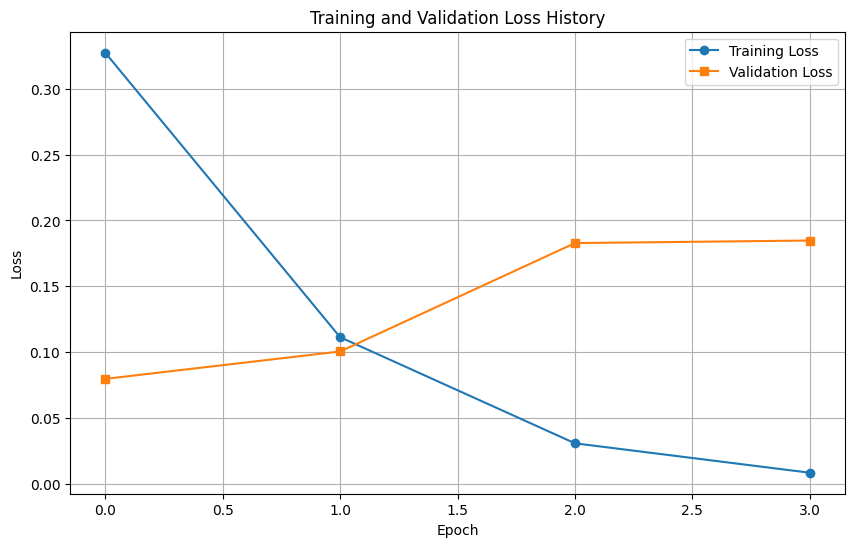

In [23]:
# Построение графика лосса от эпох
plt.figure(figsize=(10, 6))
plt.plot(train_l, label='Training Loss', marker='o')
plt.plot(val_l, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss History')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# Загружаем лучшую модель для финального тестирования
model.load_state_dict(torch.load('best_model.pth', map_location=device))

model.to(device).eval()

final_predictions = []
final_labels = []

# Сбор предсказаний на тестовом наборе
with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device).float()

        outputs = model(input_ids, attention_mask)
        predictions = torch.sigmoid(outputs).cpu().numpy()

        final_predictions.extend(predictions)
        final_labels.extend(labels.cpu().numpy())

# Конвертация в массивы
final_predictions = np.array(final_predictions).ravel()  # Важно: flatten для бинарной задачи
final_labels = np.array(final_labels).ravel()

  0%|          | 0/79 [00:00<?, ?it/s]

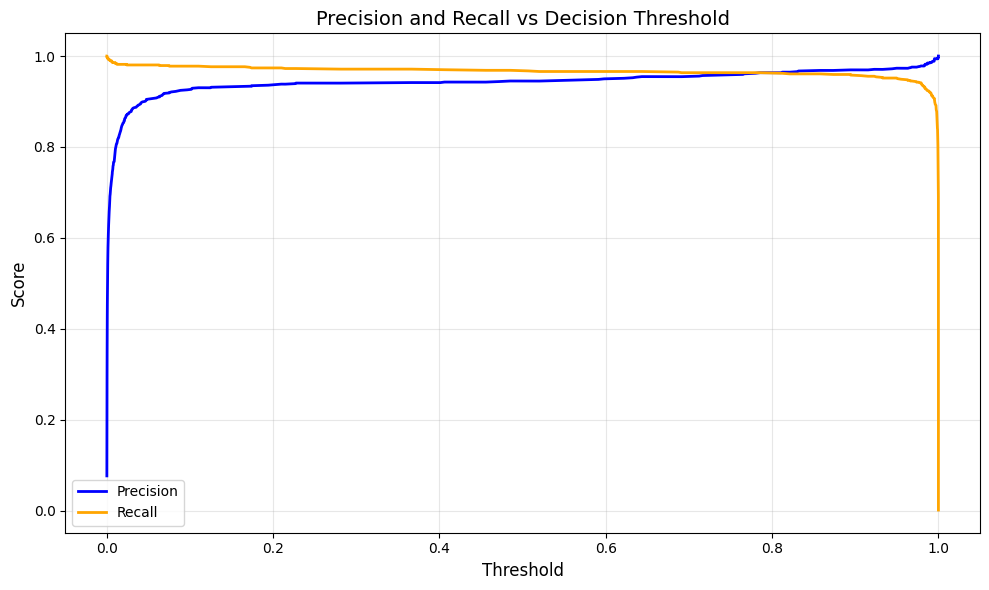

In [27]:
# --- Precision-Recall vs Threshold ---
# Расчет метрик для разных порогов
precisions, recalls, thresholds = precision_recall_curve(final_labels, final_predictions)

# Построение графика зависимости от порога
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', linewidth=2, color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', linewidth=2, color='orange')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision and Recall vs Decision Threshold', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


CLASSIFICATION REPORT (threshold=0.5)
              precision    recall  f1-score   support

         0.0     0.9973    0.9953    0.9963      9236
         1.0     0.9450    0.9673    0.9560       764

    accuracy                         0.9932     10000
   macro avg     0.9712    0.9813    0.9762     10000
weighted avg     0.9933    0.9932    0.9932     10000


CONFUSION MATRIX (threshold=0.5)


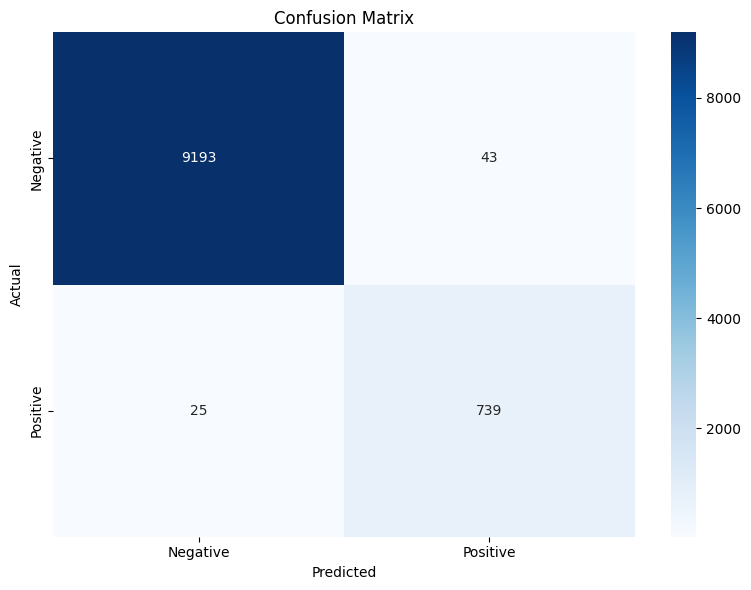

In [34]:
# Бинаризация предсказаний для основных метрик
threshold = 0.5
final_predictions_binary = (final_predictions > threshold).astype(int)

# --- Classification Report ---
print('\n' + '='*50)
print(f'CLASSIFICATION REPORT (threshold={threshold})')
print('='*50)
print(classification_report(final_labels, final_predictions_binary, digits=4))

# --- Confusion Matrix ---
print('\n' + '='*50)
print(f'CONFUSION MATRIX (threshold={threshold})')
print('='*50)
cm = confusion_matrix(final_labels, final_predictions_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [37]:
# Создаем обертку для модели, которая добавляет reshape
class ModelWithReshape(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.original_model = original_model

    def forward(self, input_ids, attention_mask):
        output = self.original_model(input_ids, attention_mask)
        # Добавляем размерность: [batch] -> [batch, 1]
        output = output.unsqueeze(-1)  # или output.reshape(-1, 1)
        return output

# Конвертация с оберткой
def convert_to_onnx(model, tokenizer, device, output_path="model.onnx", max_length=64):
    model.eval()

    # Оборачиваем модель
    wrapped_model = ModelWithReshape(model)
    wrapped_model.eval()

    dummy_text = "dummy text for onnx export"
    dummy_inputs = tokenizer(dummy_text, truncation=True, padding='max_length',
                            max_length=max_length, return_tensors='pt')

    dummy_input_ids = dummy_inputs['input_ids'].to(device)
    dummy_attention_mask = dummy_inputs['attention_mask'].to(device)

    # Экспортируем обернутую модель
    torch.onnx.export(
        wrapped_model,  # используем обертку
        (dummy_input_ids, dummy_attention_mask),
        output_path,
        input_names=['input_ids', 'attention_mask'],
        output_names=['output'],
        dynamic_axes={
            'input_ids': {0: 'batch_size'},
            'attention_mask': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        },
        opset_version=14
    )

    print(f"Модель с выходом размерности [batch, 1] сохранена в {output_path}")

# Сохраняем модель
convert_to_onnx(model, tokenizer, device, "model.onnx", MAX_LENGTH)

/tmp/ipykernel_11991/3038715482.py:29: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0826 16:04:43.826000 11991 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0826 16:04:48.063000 11991 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0826 16:04:48.066000 11991 torch/onnx/_internal/exporter/_registration.py:110] torchv

[torch.onnx] Obtain model graph for `ModelWithReshape([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ModelWithReshape([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: /project/onnx/version_converter/adapters/no_previous_version.h:24: adap

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Модель с выходом размерности [batch, 1] сохранена в model.onnx
